# 🎙️ Gemastik 2026: 5-Fold Stratified GroupKFold Audio Wav2Vec2 Classifier

This notebook implements the **5-Fold Stratified GroupKFold Audio Wav2Vec2 Fine-Tuning Pipeline** for Stage 1 Deepfake Audio Detection using **`MelodyMachine/Deepfake-audio-detection-V2`**.

### 🔑 Key Engineering & Scientific Features:
1. **Strict Split Consistency:** Strictly loads `kfold_splits.json` from Google Drive (Zero data leakage, balanced class ratios).
2. **Train-Set-Only Audio Augmentations (Section 2B.3):** On-the-fly Additive Gaussian Noise (SNR 15-30 dB), Random Gain (\pm 6 dB), and Time Shift (\pm 10%).
4. **L4 GPU Optimizations:** `BATCH_SIZE = 16`, AMP Mixed Precision FP16, `num_workers = 4`, `pin_memory = True`.
5. **Dynamic LR Scheduler & Early Stopping:** `ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6)` and Early Stopping (`patience=3`).
6. **Smart Skip Retraining:** Checks if trained fold checkpoints exist in Google Drive (`models/revision1/`) before retraining.
7. **Out-of-Fold Metrics & Visualizations:** Subplot Heatmaps for Folds 1 to 5 + Master Combined Out-of-Fold Confusion Matrix.
8. **Independent Held-Out Test Set Evaluation:** Unzips `testReal.zip` & `testAI.zip` and evaluates the 5-Fold Soft Voting Ensemble.

## 1. Setup Environment & L4 GPU Hardware Check

In [1]:
import os
import sys
import glob
import json
import shutil
import random
import zipfile
import subprocess
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchaudio
import torchaudio.transforms as T
import librosa
import soundfile as sf

from transformers import AutoProcessor, AutoModelForAudioClassification, Wav2Vec2FeatureExtractor
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# Set random seeds for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# GPU Hardware Check & Drive Mount
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ PyTorch Device: {device}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"🎮 Active GPU: {gpu_name} ({vram_gb:.2f} GB VRAM)")
else:
    print("⚠️ Warning: GPU not detected! Execution will fall back to CPU.")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive mounted successfully.")
except Exception as e:
    print(f"ℹ️ Not running on Google Colab or Drive already mounted ({e}).")


⚡ PyTorch Device: cuda
🎮 Active GPU: NVIDIA L4 (22.03 GB VRAM)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully.


## 2. Model Backbone & Dynamic Hyperparameter Configuration

In [2]:
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, Wav2Vec2FeatureExtractor
# Candidate paths to search for hyperparameter profile 'audio_colab_L4.json'
json_name = "audio_colab_L4.json"
search_paths = [
    os.path.join("notebook/revision1/hyperparameter", json_name),
    os.path.join("hyperparameter", json_name),
    os.path.join("/content/notebook/revision1/hyperparameter", json_name),
    os.path.join("/content/mancing-tipu/notebook/revision1/hyperparameter", json_name),
    os.path.join("/content/drive/MyDrive/Gemastik26/hyperparameter", json_name)
]

default_hp = {
  "modality": "audio",
  "gpu_profile": "audio_colab_L4",
  "gpu_name": "NVIDIA L4",
  "vram_gb": 24,
  "hf_model_id": "MelodyMachine/Deepfake-audio-detection-V2",
  "batch_size": 16,
  "epochs": 10,
  "learning_rate": 3e-05,
  "weight_decay": 0.01,
  "sample_rate": 16000,
  "audio_chunk_duration_sec": 5.0,
  "max_audio_samples": 80000,
  "num_workers": 4,
  "pin_memory": True,
  "persistent_workers": True,
  "use_amp_fp16": True,
  "early_stopping_patience": 3,
  "model_save_dir": "/content/drive/MyDrive/Gemastik26/models/revision1",
  "kfold_splits_file": "/content/drive/MyDrive/Gemastik26/kfold_splits.json",
  "scheduler_type": "CosineAnnealingLR",
  "min_lr": 1e-06
}

CONFIG_PATH = None
for p in search_paths:
    if os.path.exists(p):
        CONFIG_PATH = p
        break

if CONFIG_PATH:
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        hp = json.load(f)
    # Force learning_rate to 3e-5 (0.00003) and CosineAnnealingLR
    hp["learning_rate"] = 3e-5
    hp["scheduler_type"] = "CosineAnnealingLR"
    with open(CONFIG_PATH, "w", encoding="utf-8") as f:
        json.dump(hp, f, indent=2)
    print(f"⚙️ Loaded & Enforced Hyperparameter Profile from '{CONFIG_PATH}': {hp.get('gpu_profile', json_name)}")
else:
    hp = default_hp
    os.makedirs("hyperparameter", exist_ok=True)
    local_save = os.path.join("hyperparameter", json_name)
    with open(local_save, "w", encoding="utf-8") as f:
        json.dump(hp, f, indent=2)
    drive_dir = "/content/drive/MyDrive/Gemastik26/hyperparameter"
    if os.path.exists("/content/drive/MyDrive"):
        os.makedirs(drive_dir, exist_ok=True)
        with open(os.path.join(drive_dir, json_name), "w", encoding="utf-8") as f:
            json.dump(hp, f, indent=2)
    print(f"⚙️ Embedded Hyperparameter Profile Initialized & Saved to '{local_save}'")

HF_MODEL_ID = hp["hf_model_id"]
BATCH_SIZE = hp.get("batch_size", 16)
EPOCHS = hp.get("epochs", 10)
LEARNING_RATE = hp.get("learning_rate", 3e-5)
WEIGHT_DECAY = hp.get("weight_decay", 0.01)
SAMPLE_RATE = hp.get("sample_rate", 16000)
CHUNK_DURATION_SEC = hp.get("audio_chunk_duration_sec", 5.0)
MAX_AUDIO_SAMPLES = int(SAMPLE_RATE * CHUNK_DURATION_SEC)
NUM_WORKERS = hp.get("num_workers", 4)
PATIENCE = hp.get("early_stopping_patience", 3)
MIN_LR = hp.get("min_lr", 1e-6)

MODEL_SAVE_DIR = hp.get("model_save_dir", "/content/drive/MyDrive/Gemastik26/models/revision1")
KFOLD_SPLIT_FILE = hp.get("kfold_splits_file", "/content/drive/MyDrive/Gemastik26/kfold_splits.json")
DRIVE_DATASET_DIR = "/content/drive/MyDrive/Gemastik26/Dataset Indonesia"
CLASSES = ["Real", "AI"]
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

feature_extractor = AutoFeatureExtractor.from_pretrained(HF_MODEL_ID)

print(f"⚙️ ACTIVE AUDIO HYPERPARAMETERS:")
print(f"   Backbone: {HF_MODEL_ID} | Batch Size: {BATCH_SIZE} | Learning Rate: {LEARNING_RATE} | Epochs: {EPOCHS}")
print(f"   Sample Rate: {SAMPLE_RATE} Hz | Chunk Duration: {CHUNK_DURATION_SEC}s ({MAX_AUDIO_SAMPLES} samples)")
print(f"   Model Save Path: {MODEL_SAVE_DIR}")


⚙️ Loaded & Enforced Hyperparameter Profile from 'hyperparameter/audio_colab_L4.json': audio_colab_L4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


⚙️ ACTIVE AUDIO HYPERPARAMETERS:
   Backbone: MelodyMachine/Deepfake-audio-detection-V2 | Batch Size: 16 | Learning Rate: 3e-05 | Epochs: 10
   Sample Rate: 16000 Hz | Chunk Duration: 5.0s (80000 samples)
   Model Save Path: /content/drive/MyDrive/Gemastik26/models/revision1


## 3. Unzip Video/Audio Archives & Audio Extraction (16kHz Mono)

In [3]:
LOCAL_RAW_DIR = "/content/dataset_raw"
LOCAL_AUDIO_DIR = "/content/dataset_audio_16k"
os.makedirs(LOCAL_RAW_DIR, exist_ok=True)
os.makedirs(LOCAL_AUDIO_DIR, exist_ok=True)

ZIP_PATHS = {
    "Real": os.path.join(DRIVE_DATASET_DIR, "Real", "train.zip"),
    "AI": os.path.join(DRIVE_DATASET_DIR, "AI", "trainAI.zip")
}

def unzip_file(zip_path, extract_to):
    print(f"📦 Unzipping '{zip_path}' -> '{extract_to}'...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"✅ Unzipped to {extract_to}")

for cls, zpath in ZIP_PATHS.items():
    target_dir = os.path.join(LOCAL_RAW_DIR, cls)
    if os.path.exists(target_dir) and len(os.listdir(target_dir)) > 0:
        print(f"⏭️ Target directory '{target_dir}' already exists. Skipping unzip.")
    elif os.path.exists(zpath):
        unzip_file(zpath, target_dir)
    else:
        print(f"⚠️ Zip file not found: {zpath}")

# Extract 16kHz Mono Audio Files from Videos with robust fallback
def extract_audio_from_video(video_path, output_wav_path, target_sr=16000):
    # Try FFmpeg first
    cmd = [
        "ffmpeg", "-y", "-i", video_path, "-vn",
        "-acodec", "pcm_s16le", "-ar", str(target_sr), "-ac", "1",
        output_wav_path
    ]
    res = subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    if not os.path.exists(output_wav_path) or os.path.getsize(output_wav_path) < 100:
        try:
            # Fallback to librosa/soundfile audio extraction
            y, sr = librosa.load(video_path, sr=target_sr, mono=True)
            sf.write(output_wav_path, y, target_sr)
        except Exception as e:
            pass

for cls in CLASSES:
    cls_raw_dir = os.path.join(LOCAL_RAW_DIR, cls)
    cls_audio_dir = os.path.join(LOCAL_AUDIO_DIR, cls)
    os.makedirs(cls_audio_dir, exist_ok=True)
    
    if not os.path.exists(cls_raw_dir):
        print(f"⚠️ Raw video folder for {cls} does not exist at: {cls_raw_dir}")
        continue
        
    video_extensions = ("*.mp4", "*.avi", "*.mov", "*.mkv", "*.MP4", "*.AVI", "*.MOV", "*.MKV")
    video_files = []
    for ext in video_extensions:
        video_files.extend(glob.glob(os.path.join(cls_raw_dir, "**", ext), recursive=True))
    
    print(f"🎙️ Extracting 16kHz Mono WAV audio for {len(video_files)} {cls} videos ...")
    extracted_count = 0
    for vid in tqdm(video_files, desc=f"Audio Extraction [{cls}]"):
        v_stem = Path(vid).stem
        out_wav = os.path.join(cls_audio_dir, f"{v_stem}.wav")
        if not os.path.exists(out_wav) or os.path.getsize(out_wav) < 100:
            extract_audio_from_video(vid, out_wav, target_sr=SAMPLE_RATE)
        if os.path.exists(out_wav) and os.path.getsize(out_wav) > 100:
            extracted_count += 1
    print(f"✅ Successfully processed {extracted_count} / {len(video_files)} {cls} audio files.")


⏭️ Target directory '/content/dataset_raw/Real' already exists. Skipping unzip.
⏭️ Target directory '/content/dataset_raw/AI' already exists. Skipping unzip.
🎙️ Extracting 16kHz Mono WAV audio for 654 Real videos ...


Audio Extraction [Real]:   0%|          | 0/654 [00:00<?, ?it/s]/tmp/ipykernel_32391/2527283319.py:38: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(video_path, sr=target_sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Audio Extraction [Real]:  10%|▉         | 63/654 [00:00<00:08, 71.28it/s]/tmp/ipykernel_32391/2527283319.py:38: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(video_path, sr=target_sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Audio Ext

✅ Successfully processed 651 / 654 Real audio files.
🎙️ Extracting 16kHz Mono WAV audio for 413 AI videos ...


Audio Extraction [AI]:   0%|          | 0/413 [00:00<?, ?it/s]/tmp/ipykernel_32391/2527283319.py:38: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(video_path, sr=target_sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Audio Extraction [AI]:  48%|████▊     | 198/413 [00:00<00:00, 1109.45it/s]/tmp/ipykernel_32391/2527283319.py:38: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(video_path, sr=target_sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Audio Extr

✅ Successfully processed 411 / 413 AI audio files.


## 4. Load 5-Fold Stratified GroupKFold Split (`kfold_splits.json`)

In [4]:
all_audio_samples = []
# Note: MelodyMachine pretrained head uses 0=fake/AI, 1=real/Real
for cls in CLASSES:
    label_idx = 1 if cls == "Real" else 0
    cls_dir = os.path.join(LOCAL_AUDIO_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    wav_files = glob.glob(os.path.join(cls_dir, "*.wav"))
    for wf in wav_files:
        v_stem = Path(wf).stem
        all_audio_samples.append((wf, label_idx, v_stem))

print(f"📊 Total Extracted Audio Samples Found: {len(all_audio_samples)}")
if len(all_audio_samples) == 0:
    print("⚠️ WARNING: 0 audio files found! Please make sure Section 3 (unzip & audio extraction) was executed!")

# 🛡️ STRICT 5-FOLD SPLIT LOADING (Must be generated by generate_kfold_split.ipynb)
if os.path.exists(KFOLD_SPLIT_FILE):
    with open(KFOLD_SPLIT_FILE, "r", encoding="utf-8") as f:
        kfold_splits = json.load(f)
    print(f"✅ LOADED 5-FOLD SPLIT DICTIONARY FROM DRIVE:")
    print(f"➡️ {KFOLD_SPLIT_FILE}")
else:
    raise FileNotFoundError(
        f"❌ ERROR: 5-Fold split file not found at: {KFOLD_SPLIT_FILE}\n"
        f"Please execute 'generate_kfold_split.ipynb' first to generate and export kfold_splits.json to Drive!"
    )

print(f"📊 Active Folds Loaded: {list(kfold_splits.keys())}")
for f_name, f_data in kfold_splits.items():
    print(f"   - {f_name}: {len(f_data['train_stems'])} Train Stems | {len(f_data['val_stems'])} Val Stems")


📊 Total Extracted Audio Samples Found: 1062
✅ LOADED 5-FOLD SPLIT DICTIONARY FROM DRIVE:
➡️ /content/drive/MyDrive/Gemastik26/kfold_splits.json
📊 Active Folds Loaded: ['fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5']
   - fold_1: 853 Train Stems | 214 Val Stems
   - fold_2: 854 Train Stems | 213 Val Stems
   - fold_3: 853 Train Stems | 214 Val Stems
   - fold_4: 854 Train Stems | 213 Val Stems
   - fold_5: 854 Train Stems | 213 Val Stems


## 5. PyTorch Audio Dataset & Audio Augmentations (Section 2B.3)
### 🎨 Train-Set-Only Audio Waveform Augmentation Pipeline
- **Additive Gaussian Noise:** $\text{SNR} \in [15, 30]\text{ dB}$ (`p=0.5`)
- **Random Gain:** Gain scale $\in [-6\text{ dB}, +6\text{ dB}]$ (`p=0.5`)
- **Time Shift:** Shift up to $\pm 10\%$ (`p=0.5`)
- **5-Second Non-Overlapping Chunking:** 5s windows (80,000 samples at 16kHz) with non-overlapping 5s stride (`stride_samples = max_samples`).

In [5]:
def apply_audio_augmentations(waveform, sample_rate=16000):
    # 1. Additive Gaussian Noise (SNR 15-30 dB)
    if random.random() < 0.5:
        snr_db = random.uniform(15.0, 30.0)
        signal_power = torch.mean(waveform ** 2)
        if signal_power > 0:
            noise_power = signal_power / (10 ** (snr_db / 10.0))
            noise = torch.randn_like(waveform) * torch.sqrt(noise_power)
            waveform = waveform + noise
    
    # 2. Random Gain (-6 dB to +6 dB)
    if random.random() < 0.5:
        gain_db = random.uniform(-6.0, 6.0)
        gain_scale = 10 ** (gain_db / 20.0)
        waveform = waveform * gain_scale
    
    # 3. Time Shift (\pm 10% shift)
    if random.random() < 0.5:
        shift_amt = int(random.uniform(-0.1, 0.1) * waveform.shape[-1])
        waveform = torch.roll(waveform, shifts=shift_amt, dims=-1)
        
    return waveform

class AudioChunkDataset(Dataset):
    def __init__(self, samples, target_sr=16000, max_samples=80000, augment=False):
        self.chunk_samples = []
        self.target_sr = target_sr
        self.max_samples = max_samples
        self.augment = augment
        
        stride_samples = max_samples  # Non-overlapping 5-second chunk stride
        error_count = 0
        for wav_path, label in samples:
            try:
                waveform = None
                try:
                    waveform, sr = torchaudio.load(wav_path)
                except Exception:
                    y, sr = librosa.load(wav_path, sr=target_sr, mono=True)
                    waveform = torch.from_numpy(y).unsqueeze(0)
                
                if waveform is None or waveform.shape[-1] == 0:
                    error_count += 1
                    continue
                
                if waveform.shape[0] > 1:
                    waveform = torch.mean(waveform, dim=0, keepdim=True)
                if sr != target_sr:
                    resampler = T.Resample(sr, target_sr)
                    waveform = resampler(waveform)
                
                total_len = waveform.shape[-1]
                if total_len <= max_samples:
                    pad_len = max_samples - total_len
                    chunk = F.pad(waveform, (0, pad_len))
                    self.chunk_samples.append((chunk, label))
                else:
                    for start in range(0, total_len - max_samples + 1, stride_samples):
                        chunk = waveform[:, start:start + max_samples]
                        self.chunk_samples.append((chunk, label))
            except Exception as e:
                error_count += 1
                continue
        
        if len(self.chunk_samples) == 0:
            print(f"⚠️ Warning: AudioChunkDataset created 0 chunks out of {len(samples)} samples (Errors: {error_count})")

    def __len__(self):
        return len(self.chunk_samples)

    def __getitem__(self, idx):
        waveform, label = self.chunk_samples[idx]
        if self.augment:
            waveform = apply_audio_augmentations(waveform, sample_rate=self.target_sr)
        inputs = feature_extractor(waveform.squeeze(0).numpy(), sampling_rate=self.target_sr, do_normalize=True, return_tensors="pt")
        input_values = inputs.input_values.squeeze(0)
        return input_values, label

print("✅ Loaded Section 2B.3 Train-Only Audio Waveform Augmentation Dataset (Non-Overlapping 5s Chunks)!")


✅ Loaded Section 2B.3 Train-Only Audio Waveform Augmentation Dataset (Non-Overlapping 5s Chunks)!


## 6. L4-Optimized 5-Fold Fine-Tuning Pipeline (`train_wav2vec2_kfold_pipeline`)

In [6]:
def train_wav2vec2_kfold_pipeline(model_tag="AUGMENTED_AUDIO", epochs=EPOCHS, patience=PATIENCE, force_retrain=False):
    fold_results = []
    all_fold_histories = {}
    oof_predictions = {}
    
    print(f"========================================================")
    print(f"🚀 STARTING 5-FOLD CROSS-VALIDATION FINE-TUNING [{model_tag}]")
    print(f"   Backbone: {HF_MODEL_ID} | Batch Size: {BATCH_SIZE} | LR: {LEARNING_RATE}")
    print(f"========================================================")
    
    for fold_name, split_info in kfold_splits.items():
        print(f"\n--- 🔄 Processing {fold_name.upper()} ---")
        train_stems = set(split_info["train_stems"])
        val_stems = set(split_info["val_stems"])
        
        train_samples = [(path, lbl) for path, lbl, stem in all_audio_samples if stem in train_stems]
        val_samples = [(path, lbl) for path, lbl, stem in all_audio_samples if stem in val_stems]
        
        save_folder_name = f"melody_audio_aug_{fold_name}"
        target_save_path = os.path.join(MODEL_SAVE_DIR, save_folder_name)
        val_ds = AudioChunkDataset(val_samples, target_sr=SAMPLE_RATE, max_samples=MAX_AUDIO_SAMPLES, augment=False)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
        
        if os.path.exists(target_save_path) and not force_retrain:
            print(f"📂 Existing model found at '{target_save_path}'. Loading & evaluating on test fold...")
            eval_model = AutoModelForAudioClassification.from_pretrained(target_save_path).to(device)
            eval_model.eval()
            
            preds_list, targets_list = [], []
            with torch.no_grad():
                for inputs, lbls in tqdm(val_loader, desc=f"[{fold_name}] Test Eval"):
                    inputs = inputs.to(device)
                    with torch.cuda.amp.autocast():
                        outputs = eval_model(inputs)
                        logits = outputs.logits if hasattr(outputs, 'logits') else outputs
                    _, preds = torch.max(logits, 1)
                    preds_list.extend(preds.cpu().numpy())
                    targets_list.extend(lbls.numpy())
            
            acc = accuracy_score(targets_list, preds_list)
            prec, rec, f1, _ = precision_recall_fscore_support(targets_list, preds_list, average="macro", zero_division=0)
            fold_results.append({
                "Fold": fold_name,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "Macro_F1": f1,
                "Save_Path": target_save_path
            })
            oof_predictions[fold_name] = {"targets": targets_list, "preds": preds_list}
            del eval_model
            torch.cuda.empty_cache()
            continue
        
        # Load Fresh Wav2Vec2 Model for Fold (Matches MelodyMachine pretrained head: 0=AI, 1=Real)
        model = AutoModelForAudioClassification.from_pretrained(
            HF_MODEL_ID,
            num_labels=len(CLASSES),
            ignore_mismatched_sizes=True,
            id2label={0: "AI", 1: "Real"},
            label2id={"AI": 0, "Real": 1}
        ).to(device)
        
        train_ds = AudioChunkDataset(train_samples, target_sr=SAMPLE_RATE, max_samples=MAX_AUDIO_SAMPLES, augment=True)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=MIN_LR)
        scaler = torch.cuda.amp.GradScaler()
        
        best_val_loss = float('inf')
        epochs_no_improve = 0
        history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
        
        for epoch in range(1, epochs + 1):
            model.train()
            running_loss, correct, total = 0.0, 0, 0
            pbar = tqdm(train_loader, desc=f"[{fold_name}] Epoch {epoch}/{epochs} Train")
            for inputs, lbls in pbar:
                inputs, lbls = inputs.to(device), lbls.to(device)
                optimizer.zero_grad()
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    logits = outputs.logits if hasattr(outputs, 'logits') else outputs
                    loss = criterion(logits, lbls)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                
                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(logits, 1)
                correct += torch.sum(preds == lbls.data).item()
                total += lbls.size(0)
                pbar.set_postfix({"loss": f"{loss.item():.4f}"})
            
            ep_tr_loss = running_loss / total
            ep_tr_acc = correct / total
            history["train_loss"].append(ep_tr_loss)
            history["train_acc"].append(ep_tr_acc)
            
            # Validation Phase
            model.eval()
            val_loss_sum, val_corr, val_tot = 0.0, 0, 0
            with torch.no_grad():
                for inputs, lbls in val_loader:
                    inputs, lbls = inputs.to(device), lbls.to(device)
                    with torch.cuda.amp.autocast():
                        outputs = model(inputs)
                        logits = outputs.logits if hasattr(outputs, 'logits') else outputs
                        loss = criterion(logits, lbls)
                    val_loss_sum += loss.item() * inputs.size(0)
                    _, preds = torch.max(logits, 1)
                    val_corr += torch.sum(preds == lbls.data).item()
                    val_tot += lbls.size(0)
            
            ep_val_loss = val_loss_sum / val_tot
            ep_val_acc = val_corr / val_tot
            history["val_loss"].append(ep_val_loss)
            history["val_acc"].append(ep_val_acc)
            scheduler.step()
            
            print(f"[{fold_name}] Ep {epoch:02d}/{epochs:02d} | Train Loss: {ep_tr_loss:.4f} Acc: {ep_tr_acc*100:.2f}% | Val Loss: {ep_val_loss:.4f} Acc: {ep_val_acc*100:.2f}%")
            
            if ep_val_loss < best_val_loss:
                best_val_loss = ep_val_loss
                epochs_no_improve = 0
                model.save_pretrained(target_save_path)
                feature_extractor.save_pretrained(target_save_path)
                print(f"  🏆 Saved best model for {fold_name} to: {target_save_path}")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"  🛑 Early stopping triggered for {fold_name} at epoch {epoch}.")
                    break
        
        all_fold_histories[fold_name] = history
        
        # Evaluate best fold checkpoint
        eval_model = AutoModelForAudioClassification.from_pretrained(target_save_path).to(device)
        eval_model.eval()
        preds_list, targets_list = [], []
        with torch.no_grad():
            for inputs, lbls in val_loader:
                inputs = inputs.to(device)
                with torch.cuda.amp.autocast():
                    outputs = eval_model(inputs)
                    logits = outputs.logits if hasattr(outputs, 'logits') else outputs
                _, preds = torch.max(logits, 1)
                preds_list.extend(preds.cpu().numpy())
                targets_list.extend(lbls.numpy())
        
        acc = accuracy_score(targets_list, preds_list)
        prec, rec, f1, _ = precision_recall_fscore_support(targets_list, preds_list, average="macro", zero_division=0)
        fold_results.append({
            "Fold": fold_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "Macro_F1": f1,
            "Save_Path": target_save_path
        })
        oof_predictions[fold_name] = {"targets": targets_list, "preds": preds_list}
        
        del model, eval_model
        torch.cuda.empty_cache()
    
    return fold_results, all_fold_histories, oof_predictions


## 7. Run 5-Fold Audio Training & Fine-Tuning Execution

In [7]:
fold_results, fold_histories, oof_predictions = train_wav2vec2_kfold_pipeline(
    model_tag="AUGMENTED_AUDIO",
    epochs=EPOCHS,
    patience=PATIENCE,
    force_retrain=False
)


🚀 STARTING 5-FOLD CROSS-VALIDATION FINE-TUNING [AUGMENTED_AUDIO]
   Backbone: MelodyMachine/Deepfake-audio-detection-V2 | Batch Size: 16 | LR: 3e-05

--- 🔄 Processing FOLD_1 ---


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

/tmp/ipykernel_32391/3268914854.py:70: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
[fold_1] Epoch 1/10 Train:   0%|          | 0/541 [00:00<?, ?it/s]/tmp/ipykernel_32391/3268914854.py:83: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[fold_1] Epoch 1/10 Train: 100%|██████████| 541/541 [02:26<00:00,  3.69it/s, loss=0.0383]
/tmp/ipykernel_32391/3268914854.py:108: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[fold_1] Ep 01/10 | Train Loss: 0.2998 Acc: 91.26% | Val Loss: 0.0877 Acc: 97.80%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

[fold_5] Ep 06/10 | Train Loss: 0.0321 Acc: 99.14% | Val Loss: 0.0638 Acc: 98.68%


[fold_5] Epoch 7/10 Train: 100%|██████████| 553/553 [02:28<00:00,  3.73it/s, loss=0.0021]


[fold_5] Ep 07/10 | Train Loss: 0.0235 Acc: 99.34% | Val Loss: 0.0637 Acc: 99.01%
  🛑 Early stopping triggered for fold_5 at epoch 7.


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

/tmp/ipykernel_32391/3268914854.py:146: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


## 8. 5-Fold Cross-Validation Metrics & Statistical Summary

📊 5-FOLD STRATIFIED GROUPKFOLD SUMMARY (Wav2Vec2 Audio)


,Fold,Accuracy,Precision,Recall,Macro_F1,Save_Path
0,fold_1,0.984463,0.960112,0.933012,0.946063,/content/drive/MyDrive/Gemastik26/models/revis...
1,fold_2,0.983765,0.972778,0.965091,0.968885,/content/drive/MyDrive/Gemastik26/models/revis...
2,fold_3,0.904335,0.880376,0.609747,0.652018,/content/drive/MyDrive/Gemastik26/models/revis...
3,fold_4,0.973029,0.960785,0.899857,0.927477,/content/drive/MyDrive/Gemastik26/models/revis...
4,fold_5,0.988246,0.970215,0.959529,0.964795,/content/drive/MyDrive/Gemastik26/models/revis...



--- 📈 OVERALL 5-FOLD CROSS-VALIDATION RESULTS (MEAN ± STD) ---
Accuracy:         96.68% ± 3.54%
Precision (Macro): 94.89% ± 3.87%
Recall (Macro):    87.34% ± 14.97%
Macro F1-Score:   89.18% ± 13.51%


/tmp/ipykernel_32391/1893266122.py:51: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


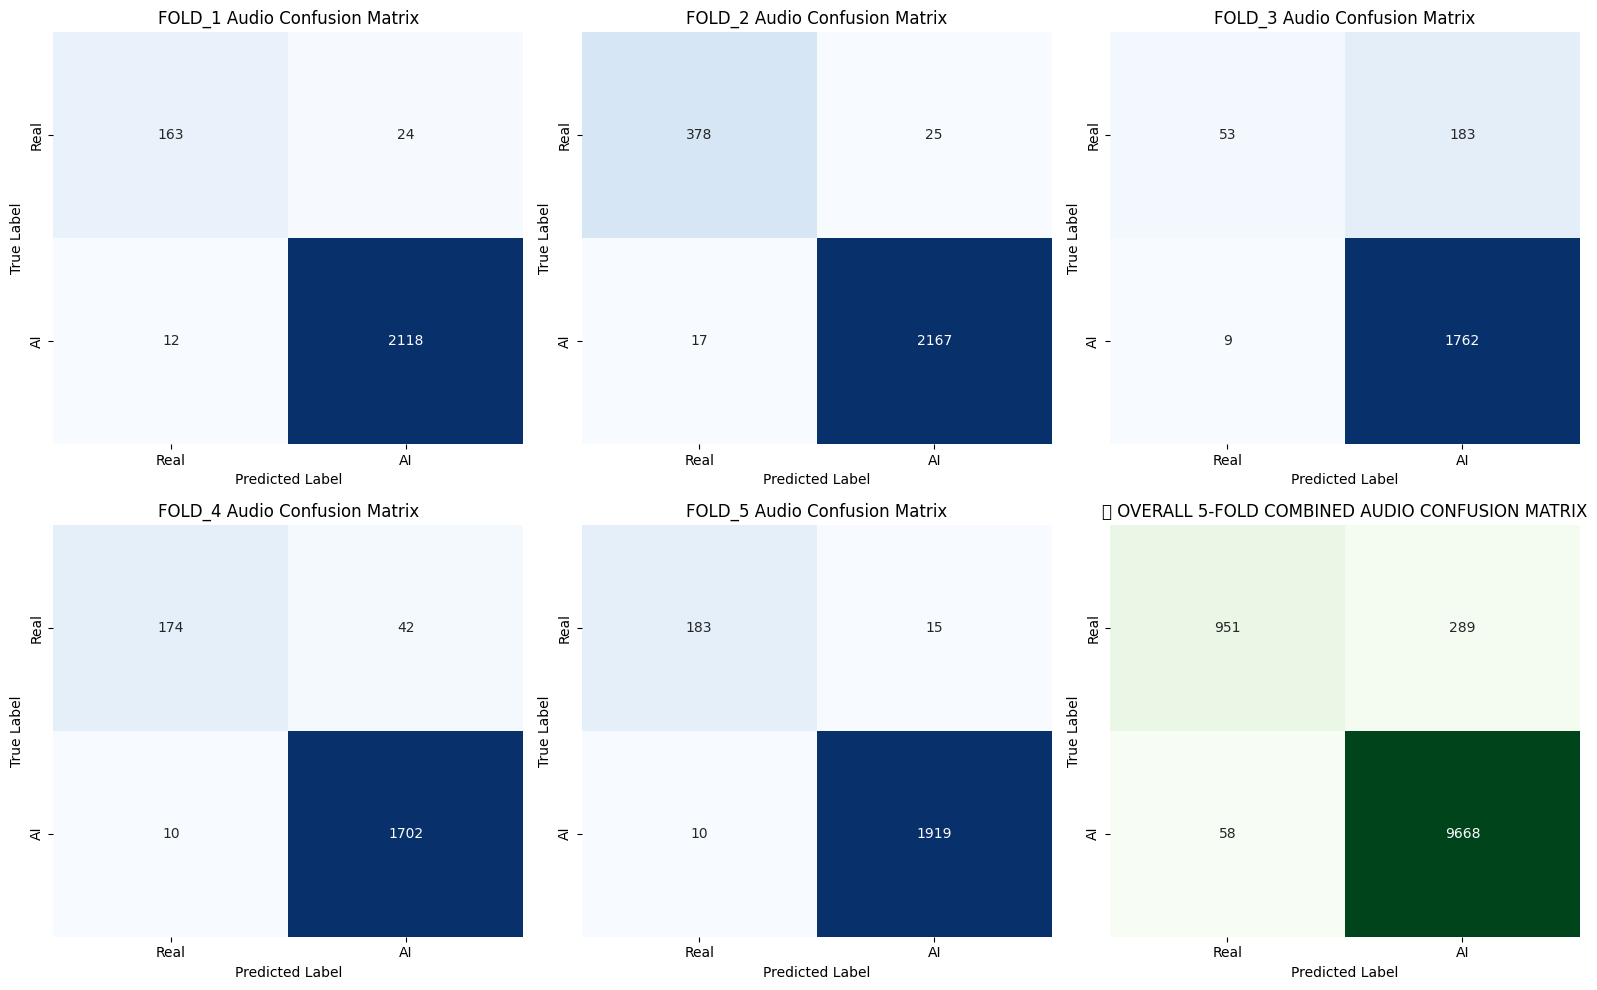


📋 OVERALL AUDIO OUT-OF-FOLD CLASSIFICATION REPORT (100% TEST DATASET)
              precision    recall  f1-score   support

        Real     0.9425    0.7669    0.8457      1240
          AI     0.9710    0.9940    0.9824      9726

    accuracy                         0.9684     10966
   macro avg     0.9567    0.8805    0.9140     10966
weighted avg     0.9678    0.9684    0.9669     10966



In [8]:
df_kfold = pd.DataFrame(fold_results)

mean_acc = df_kfold["Accuracy"].mean() * 100
std_acc = df_kfold["Accuracy"].std() * 100
mean_f1 = df_kfold["Macro_F1"].mean() * 100
std_f1 = df_kfold["Macro_F1"].std() * 100
mean_prec = df_kfold["Precision"].mean() * 100
std_prec = df_kfold["Precision"].std() * 100
mean_rec = df_kfold["Recall"].mean() * 100
std_rec = df_kfold["Recall"].std() * 100

print("===============================================================")
print("📊 5-FOLD STRATIFIED GROUPKFOLD SUMMARY (Wav2Vec2 Audio)")
print("===============================================================")
display(df_kfold)

print("\n--- 📈 OVERALL 5-FOLD CROSS-VALIDATION RESULTS (MEAN ± STD) ---")
print(f"Accuracy:         {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"Precision (Macro): {mean_prec:.2f}% ± {std_prec:.2f}%")
print(f"Recall (Macro):    {mean_rec:.2f}% ± {std_rec:.2f}%")
print(f"Macro F1-Score:   {mean_f1:.2f}% ± {std_f1:.2f}%")

# 🧩 Subplot Heatmaps across all 5 Folds & Aggregated Master Confusion Matrix
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

all_targets_combined = []
all_preds_combined = []

for fold_idx, (fold_name, res) in enumerate(oof_predictions.items()):
    y_true = res["targets"]
    y_pred = res["preds"]
    all_targets_combined.extend(y_true)
    all_preds_combined.extend(y_pred)
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[fold_idx],
                xticklabels=CLASSES, yticklabels=CLASSES)
    axes[fold_idx].set_title(f"{fold_name.upper()} Audio Confusion Matrix")
    axes[fold_idx].set_xlabel("Predicted Label")
    axes[fold_idx].set_ylabel("True Label")

# Plot Overall Combined Out-of-Fold Confusion Matrix
cm_overall = confusion_matrix(all_targets_combined, all_preds_combined)
sns.heatmap(cm_overall, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[5],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[5].set_title("🏆 OVERALL 5-FOLD COMBINED AUDIO CONFUSION MATRIX")
axes[5].set_xlabel("Predicted Label")
axes[5].set_ylabel("True Label")

plt.tight_layout()
plt.show()

print("\n===============================================================")
print("📋 OVERALL AUDIO OUT-OF-FOLD CLASSIFICATION REPORT (100% TEST DATASET)")
print("===============================================================")
print(classification_report(all_targets_combined, all_preds_combined, target_names=CLASSES, digits=4))


## 9. Single Audio 5-Fold Ensemble Inference Helper

In [11]:
def predict_audio_kfold_ensemble(audio_wav_path):
    if not os.path.exists(audio_wav_path):
        raise FileNotFoundError(f"Audio file not found at: {audio_wav_path}")
        
    waveform, sr = torchaudio.load(audio_wav_path)
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    if sr != SAMPLE_RATE:
        resampler = T.Resample(sr, SAMPLE_RATE)
        waveform = resampler(waveform)
        
    total_len = waveform.shape[-1]
    chunks = []
    if total_len <= MAX_AUDIO_SAMPLES:
        pad_len = MAX_AUDIO_SAMPLES - total_len
        chunks.append(F.pad(waveform, (0, pad_len)))
    else:
        for start in range(0, total_len - MAX_AUDIO_SAMPLES + 1, MAX_AUDIO_SAMPLES):
            chunks.append(waveform[:, start:start + MAX_AUDIO_SAMPLES])
            
    inputs_list = [feature_extractor(c.squeeze(0).numpy(), sampling_rate=SAMPLE_RATE, do_normalize=True, return_tensors="pt").input_values.squeeze(0) for c in chunks]
    tensors = torch.stack(inputs_list).to(device)
    
    ensemble_probs = []
    for fold_name in kfold_splits.keys():
        m_path = os.path.join(MODEL_SAVE_DIR, f"melody_audio_aug_{fold_name}")
        if os.path.exists(m_path):
            m = AutoModelForAudioClassification.from_pretrained(m_path).to(device)
            m.eval()
            with torch.no_grad():
                with torch.cuda.amp.autocast():
                    outputs = m(tensors)
                    probs = F.softmax(outputs.logits if hasattr(outputs, 'logits') else outputs, dim=-1).cpu().numpy()
                ensemble_probs.append(np.mean(probs, axis=0))
            del m
            torch.cuda.empty_cache()
            
    if not ensemble_probs:
        raise RuntimeError("No fine-tuned fold models found for audio ensemble evaluation!")
        
    avg_prob = np.mean(ensemble_probs, axis=0)
    # Note: 0 = AI, 1 = Real in MelodyMachine pretrained head
    ai_prob = float(avg_prob[0])
    real_prob = float(avg_prob[1])
    pred_label = "AI" if ai_prob >= real_prob else "Real"
    confidence = max(ai_prob, real_prob)
    
    print(f"🎙️ Audio File: {audio_wav_path}")
    print(f"🏆 5-Fold Ensemble Audio Prediction: {pred_label} ({confidence*100:.2f}% Confidence)")
    print(f"📊 Softmax Probabilities: Real={real_prob*100:.2f}%, AI={ai_prob*100:.2f}%")
    
    return {
        "audio_path": audio_wav_path,
        "prediction": pred_label,
        "confidence": confidence,
        "real_prob": real_prob,
        "ai_prob": ai_prob
    }


## 10. Independent Held-Out Test Set Evaluation (`testReal.zip` & `testAI.zip`)
### 🧪 Evaluates 5-Fold Ensemble Audio Model on Separate Test Archives

⏭️ Target test directory '/content/dataset_raw_test/Real' already exists. Skipping unzip.
⏭️ Target test directory '/content/dataset_raw_test/AI' already exists. Skipping unzip.
🎙️ Extracting 16kHz Mono Audio for 190 Real test videos ...


Test Audio [Real]: 100%|██████████| 190/190 [00:00<00:00, 73529.96it/s]


🎙️ Extracting 16kHz Mono Audio for 122 AI test videos ...


Test Audio [AI]: 100%|██████████| 122/122 [00:00<00:00, 65061.04it/s]


🧪 EVALUATING 5-FOLD AUDIO ENSEMBLE ON HELD-OUT TEST SET (312 Samples)


...

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

✅ Active Ensemble Audio Models Loaded: 5 / 5


Audio Ensemble Test Infer:   0%|          | 0/312 [00:00<?, ?it/s]/tmp/ipykernel_32391/2617044366.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Audio Ensemble Test Infer: 100%|██████████| 312/312 [01:38<00:00,  3.18it/s]


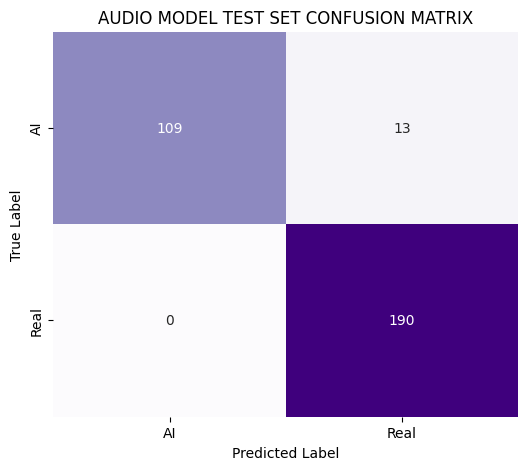


📋 INDEPENDENT HELD-OUT AUDIO TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

          AI     1.0000    0.8934    0.9437       122
        Real     0.9360    1.0000    0.9669       190

    accuracy                         0.9583       312
   macro avg     0.9680    0.9467    0.9553       312
weighted avg     0.9610    0.9583    0.9579       312



: 

In [ ]:
ZIP_TEST_PATHS = {
    "Real": [
        os.path.join(DRIVE_DATASET_DIR, "Real", "testReal.zip"),
        os.path.join(DRIVE_DATASET_DIR, "testReal.zip")
    ],
    "AI": [
        os.path.join(DRIVE_DATASET_DIR, "AI", "testAI.zip"),
        os.path.join(DRIVE_DATASET_DIR, "testAI.zip")
    ]
}

LOCAL_RAW_TEST_DIR = "/content/dataset_raw_test"
LOCAL_AUDIO_TEST_DIR = "/content/dataset_audio_test_16k"
os.makedirs(LOCAL_RAW_TEST_DIR, exist_ok=True)
os.makedirs(LOCAL_AUDIO_TEST_DIR, exist_ok=True)

# Unzip Independent Test Archives
for cls in CLASSES:
    extract_target = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    candidates = ZIP_TEST_PATHS.get(cls, [])
    found_zip = None
    for p in candidates:
        if os.path.exists(p):
            found_zip = p
            break
            
    if found_zip:
        if os.path.exists(extract_target) and len(os.listdir(extract_target)) > 0:
            print(f"⏭️ Target test directory '{extract_target}' already exists. Skipping unzip.")
        else:
            unzip_file(found_zip, extract_target)
    else:
        print(f"⚠️ Warning: Could not locate test zip for {cls} at candidates: {candidates}")

# Extract 16kHz Mono Audio Files for Test Videos
for cls in CLASSES:
    cls_raw_dir = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    cls_audio_dir = os.path.join(LOCAL_AUDIO_TEST_DIR, cls)
    os.makedirs(cls_audio_dir, exist_ok=True)
    if not os.path.exists(cls_raw_dir):
        continue
    video_extensions = ("*.mp4", "*.avi", "*.mov", "*.mkv", "*.MP4", "*.AVI", "*.MOV", "*.MKV")
    video_files = []
    for ext in video_extensions:
        video_files.extend(glob.glob(os.path.join(cls_raw_dir, "**", ext), recursive=True))
        
    print(f"🎙️ Extracting 16kHz Mono Audio for {len(video_files)} {cls} test videos ...")
    for vid in tqdm(video_files, desc=f"Test Audio [{cls}]"):
        v_stem = Path(vid).stem
        out_wav = os.path.join(cls_audio_dir, f"{v_stem}.wav")
        if os.path.exists(out_wav) and os.path.getsize(out_wav) > 1000:
            continue
        extract_audio_from_video(vid, out_wav, target_sr=SAMPLE_RATE)

# Evaluate 5-Fold Soft Voting Ensemble Audio Model on Independent Test Set
test_audio_samples = []
# Note: Model index 0 = AI, 1 = Real in MelodyMachine head
for cls in CLASSES:
    true_label = 1 if cls == "Real" else 0
    cls_dir = os.path.join(LOCAL_AUDIO_TEST_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    wav_files = glob.glob(os.path.join(cls_dir, "*.wav"))
    for wf in wav_files:
        test_audio_samples.append((wf, true_label, Path(wf).stem))

print(f"\n===============================================================")
print(f"🧪 EVALUATING 5-FOLD AUDIO ENSEMBLE ON HELD-OUT TEST SET ({len(test_audio_samples)} Samples)")
print(f"===============================================================")

ensemble_audio_models = []
for fold_name in kfold_splits.keys():
    m_path = os.path.join(MODEL_SAVE_DIR, f"melody_audio_aug_{fold_name}")
    if os.path.exists(m_path):
        m = AutoModelForAudioClassification.from_pretrained(m_path).to(device)
        m.eval()
        ensemble_audio_models.append(m)

print(f"✅ Active Ensemble Audio Models Loaded: {len(ensemble_audio_models)} / {len(kfold_splits)}")

y_true_test = []
y_pred_test = []

if len(ensemble_audio_models) > 0 and len(test_audio_samples) > 0:
    for wf, true_label, stem in tqdm(test_audio_samples, desc="Audio Ensemble Test Infer"):
        waveform, sr = torchaudio.load(wf)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
        if sr != SAMPLE_RATE:
            resampler = T.Resample(sr, SAMPLE_RATE)
            waveform = resampler(waveform)
        total_len = waveform.shape[-1]
        chunks = []
        if total_len <= MAX_AUDIO_SAMPLES:
            pad_len = MAX_AUDIO_SAMPLES - total_len
            chunks.append(F.pad(waveform, (0, pad_len)))
        else:
            for start in range(0, total_len - MAX_AUDIO_SAMPLES + 1, MAX_AUDIO_SAMPLES):
                chunks.append(waveform[:, start:start + MAX_AUDIO_SAMPLES])
                
        inputs_list = [feature_extractor(c.squeeze(0).numpy(), sampling_rate=SAMPLE_RATE, do_normalize=True, return_tensors="pt").input_values.squeeze(0) for c in chunks]
        tensors = torch.stack(inputs_list).to(device)
        
        fold_probs = []
        with torch.no_grad():
            for m in ensemble_audio_models:
                with torch.cuda.amp.autocast():
                    outputs = m(tensors)
                    probs = F.softmax(outputs.logits if hasattr(outputs, 'logits') else outputs, dim=-1).cpu().numpy()
                fold_probs.append(np.mean(probs, axis=0))
                
        ens_prob = np.mean(fold_probs, axis=0)
        pred_lbl = int(np.argmax(ens_prob))
        y_true_test.append(true_label)
        y_pred_test.append(pred_lbl)
        
    # Plot Independent Audio Test Set Confusion Matrix (Labels ordered ["AI", "Real"] matching indices 0, 1)
    fig, ax = plt.subplots(figsize=(6, 5))
    cm_test = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])
    sns.heatmap(cm_test, annot=True, fmt="d", cmap="Purples", cbar=False, ax=ax,
                xticklabels=["AI", "Real"], yticklabels=["AI", "Real"])
    ax.set_title("AUDIO MODEL TEST SET CONFUSION MATRIX")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    plt.show()
    
    print("\n===============================================================")
    print("📋 INDEPENDENT HELD-OUT AUDIO TEST SET CLASSIFICATION REPORT")
    print("===============================================================")
    print(classification_report(y_true_test, y_pred_test, labels=[0, 1], target_names=["AI", "Real"], digits=4))
else:
    print("ℹ️ Audio test samples or fine-tuned fold checkpoints not ready for test evaluation.")
